# ✈️ FLIGHT FARE PREDICTION

### 1. INTRODUCTION

Flight ticket prices fluctuate frequently due to various factors such as airline type, duration, number of stops, time of departure, and travel date. Predicting flight fares accurately helps: Airlines optimize ticket pricing, Travelers plan trips effectively, Travel websites recommend best fares


## Importing All the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


print("✅ Libraries imported! ")

✅ Libraries imported! 


## Load Data

In [2]:
# Load the dataset
flight_data = pd.read_excel("Flight_Fare.xlsx")

flight_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
flight_data.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [4]:
print(f"✅ Setup Complete. Data Shape: {flight_data.shape}")

✅ Setup Complete. Data Shape: (10683, 11)


A machine learning–based regression model is developed to predict the flight ticket price using a dataset containing 10,683 records with 11 features.

## ✅ Data Loading

- Status: Successful
- Dataset Size: The dataset contains 10,683 rows and 11 columns.
- Next Step: We will now clean the data and check for any quality issues (missing values, duplicates). 
After Cell 3: EDA & Cleaning

In [5]:
flight_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


## Information about dataset

In [6]:
flight_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [7]:
flight_data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


### Data Types

- Categorical columns: Airline, Source, Destination, Total_Stops
- Datetime columns: Date_of_Journey, Dep_Time, Arrival_Time
- Numerical column: Price

## FInding null value

In [8]:
flight_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

### DATA CLEANING AND PREPROCESSING
- Handling Missing Values

Only Route and Total_Stops had one missing value each.
These rows were filled using appropriate imputers inside ColumnTransformer.

- Removing Duplicates
All duplicate values were dropped.

## EDA & CLEANING

In [9]:
# 1. CLEANING
# Remove duplicates
flight_data = flight_data.drop_duplicates()

### Price Distribution

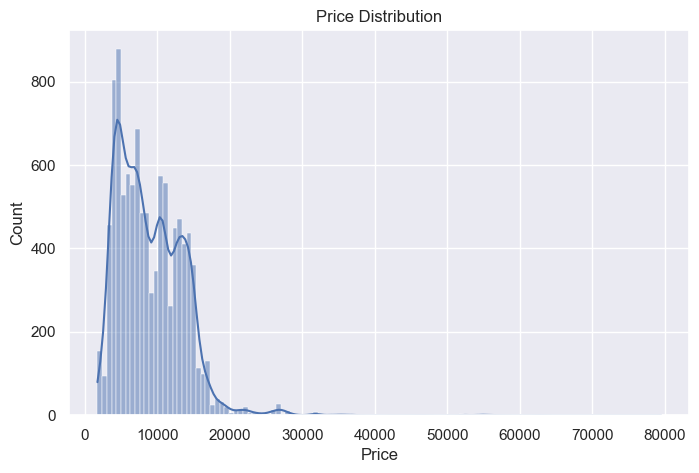

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(flight_data['Price'], kde=True)
plt.title("Price Distribution")
plt.show()

### Airline vs Price

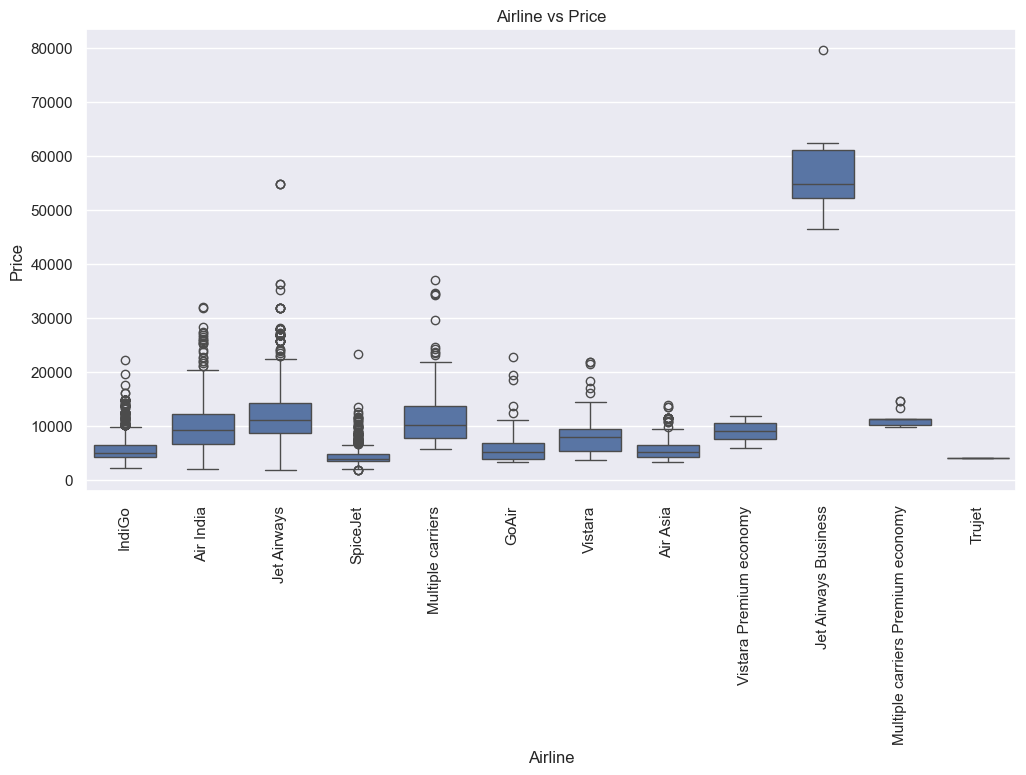

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Airline', y='Price', data=flight_data)
plt.xticks(rotation=90)
plt.title("Airline vs Price")
plt.show()

### Source vs Price

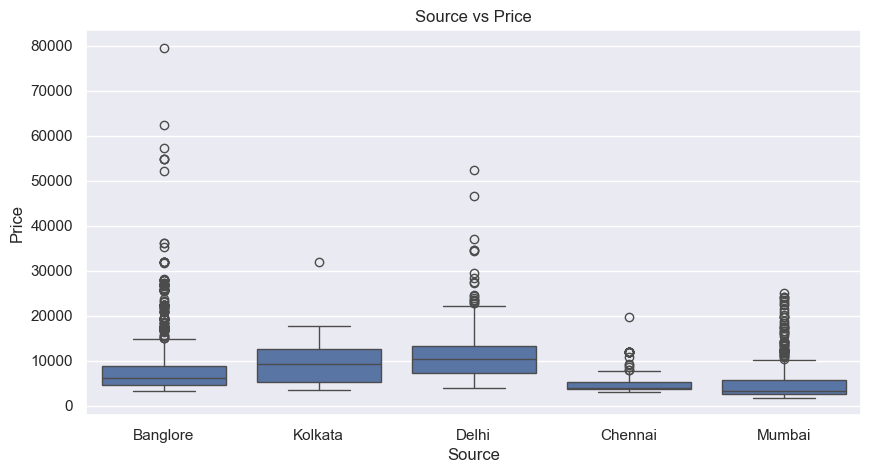

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Source', y='Price', data=flight_data)
plt.title("Source vs Price")
plt.show()

### EXPLORATORY DATA ANALYSIS (EDA)
#### Price Distribution

- A histogram and KDE plot show that flight prices are right-skewed, with most prices between ₹4,000 to ₹12,000.

#### Airline vs Price

##### Boxplots show:

- Jet Airways Business had highest fares

- IndiGo had lower & stable fares

- Air India had large variance

#### Source vs Price

- Sources with higher prices: Delhi, Mumbai

## FEATURE ENGINEERING

In [13]:
# Convert Date_of_Journey
flight_data['Date_of_Journey'] = pd.to_datetime(flight_data['Date_of_Journey'], dayfirst=True)
flight_data['Journey_Day'] = flight_data['Date_of_Journey'].dt.day
flight_data['Journey_Month'] = flight_data['Date_of_Journey'].dt.month

In [14]:
# Convert Dep_Time
flight_data['Dep_Time'] = pd.to_datetime(flight_data['Dep_Time'])
flight_data['Dep_Hour'] = flight_data['Dep_Time'].dt.hour
flight_data['Dep_Minute'] = flight_data['Dep_Time'].dt.minute

In [15]:
# Convert Arrival_Time
flight_data['Arrival_Time'] = pd.to_datetime(flight_data['Arrival_Time'])
flight_data['Arrival_Hour'] = flight_data['Arrival_Time'].dt.hour
flight_data['Arrival_Minute'] = flight_data['Arrival_Time'].dt.minute

In [16]:
# Convert Duration into minutes (Safe function)
def convert_duration(x):
    x = x.replace(" ", "")   # remove spaces like "2h 30m"
    
    hours = 0
    minutes = 0
    
    if "h" in x:
        hours = int(x.split("h")[0])
        x = x.split("h")[1]  # remaining part after hours
    if "m" in x and x != "":
        minutes = int(x.split("m")[0])
        
    return hours * 60 + minutes

flight_data['Duration_Minutes'] = flight_data['Duration'].apply(convert_duration)


In [17]:
# Convert Total Stops
flight_data['Total_Stops'] = flight_data['Total_Stops'].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

In [18]:
cols_to_drop = ['Date_of_Journey','Dep_Time','Arrival_Time','Duration','Route','Additional_Info']

flight_data.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("\nAfter Feature Engineering:")
print(flight_data.head())



After Feature Engineering:
       Airline    Source Destination  Total_Stops  Price  Journey_Day  \
0       IndiGo  Banglore   New Delhi          0.0   3897           24   
1    Air India   Kolkata    Banglore          2.0   7662            1   
2  Jet Airways     Delhi      Cochin          2.0  13882            9   
3       IndiGo   Kolkata    Banglore          1.0   6218           12   
4       IndiGo  Banglore   New Delhi          1.0  13302            1   

   Journey_Month  Dep_Hour  Dep_Minute  Arrival_Hour  Arrival_Minute  \
0              3        22          20             1              10   
1              5         5          50            13              15   
2              6         9          25             4              25   
3              5        18           5            23              30   
4              3        16          50            21              35   

   Duration_Minutes  
0               170  
1               445  
2              1140  
3           

## TRAIN-TEST SPLIT

In [19]:
# Splitting features and target
X = flight_data.drop('Price', axis=1)
y = flight_data['Price']


In [20]:
# Categorical columns
categorical_cols = ['Airline', 'Source', 'Destination']

In [21]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder='passthrough'
)

In [27]:
X = flight_data.drop('Price', axis=1)
y = flight_data['Price']

categorical_cols = ['Airline', 'Source', 'Destination']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols),

        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_cols)
    ]
)


In [29]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n✅Train/Test Split Completed!")



✅Train/Test Split Completed!


### TRAIN–TEST SPLIT

- 80% training data

- 20% testing data

## TRAINING MULTIPLE MODELS

## MODEL 1: LINEAR REGRESSION

In [33]:
model_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

print("\nTraining Linear Regression...")
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)

r2_lr = r2_score(y_test, pred_lr)
print(f"Linear Regression MAE: {mean_absolute_error(y_test, pred_lr):.4f}")
print(f"Linear Regression RMSE: {np.sqrt(mean_squared_error(y_test, pred_lr)):.4f}")
print(f"Linear Regression R2 Score: {r2_lr:.4f}")
print(f"Linear Regression Accuracy: {r2_lr*100:.2f}%")


Training Linear Regression...
Linear Regression MAE: 1957.1635
Linear Regression RMSE: 2881.8243
Linear Regression R2 Score: 0.6020
Linear Regression Accuracy: 60.20%


## MODEL 2: DECISION TREE REGRESSOR

In [34]:
model_dt = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor())
])

print("\nTraining Decision Tree Regressor...")
model_dt.fit(X_train, y_train)
pred_dt = model_dt.predict(X_test)

r2_dt = r2_score(y_test, pred_dt)
print(f"Decision Tree MAE: {mean_absolute_error(y_test, pred_dt):.4f}")
print(f"Decision Tree RMSE: {np.sqrt(mean_squared_error(y_test, pred_dt)):.4f}")
print(f"Decision Tree R2 Score: {r2_dt:.4f}")
print(f"Decision Tree Accuracy: {r2_dt*100:.2f}%")




Training Decision Tree Regressor...
Decision Tree MAE: 1447.1579
Decision Tree RMSE: 2659.7774
Decision Tree R2 Score: 0.6609
Decision Tree Accuracy: 66.09%


## MODEL 3: RANDOM FOREST REGRESSOR

In [35]:
model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

print("\nTraining Random Forest Regressor...")
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

r2_rf = r2_score(y_test, pred_rf)
print(f"Random Forest MAE: {mean_absolute_error(y_test, pred_rf):.4f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, pred_rf)):.4f}")
print(f"Random Forest R2 Score: {r2_rf:.4f}")
print(f"Random Forest Accuracy: {r2_rf*100:.2f}%")


Training Random Forest Regressor...
Random Forest MAE: 1202.9804
Random Forest RMSE: 2008.8927
Random Forest R2 Score: 0.8066
Random Forest Accuracy: 80.66%


## MODEL 4: GRADIENT BOOSTING REGRESSOR

In [36]:
model_gb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor())
])

print("\nTraining Gradient Boosting Regressor...")
model_gb.fit(X_train, y_train)
pred_gb = model_gb.predict(X_test)

r2_gb = r2_score(y_test, pred_gb)
print(f"Gradient Boosting MAE: {mean_absolute_error(y_test, pred_gb):.4f}")
print(f"Gradient Boosting RMSE: {np.sqrt(mean_squared_error(y_test, pred_gb)):.4f}")
print(f"Gradient Boosting R2 Score: {r2_gb:.4f}")
print(f"Gradient Boosting Accuracy: {r2_gb*100:.2f}%")



Training Gradient Boosting Regressor...
Gradient Boosting MAE: 1533.9986
Gradient Boosting RMSE: 2251.8321
Gradient Boosting R2 Score: 0.7570
Gradient Boosting Accuracy: 75.70%


## MODEL 5: XGBOOST REGRESSOR

In [38]:
from xgboost import XGBRegressor

model_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="rmse"
    ))
])

print("\nTraining XGBoost Regressor...")
model_xgb.fit(X_train, y_train)

# Predictions
pred_xgb = model_xgb.predict(X_test)

# Metrics
mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb = r2_score(y_test, pred_xgb)

# Accuracy (converted from R2 Score)
accuracy_xgb = r2_xgb * 100
print(f"XGBoost MAE: {mae_xgb:.4f}")
print(f"XGBoost RMSE: {rmse_xgb:.4f}")
print(f"XGBoost R2 Score: {r2_xgb:.4f}")
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}%")


Training XGBoost Regressor...
XGBoost MAE: 1139.8965
XGBoost RMSE: 1879.0037
XGBoost R2 Score: 0.8308
XGBoost Accuracy: 83.08%


# COMPARE ALL MODELS & FIND BEST MODEL


==================== MODEL PERFORMANCE COMPARISON ====================
                         Model  R2 Score
0            Linear Regression  0.601963
1      Decision Tree Regressor  0.660938
2      Random Forest Regressor  0.806580
3  Gradient Boosting Regressor  0.756970
4            XGBoost Regressor  0.830783

🏆 BEST MODEL: XGBoost Regressor
📈 BEST R2 SCORE: 0.8308
🎯 BEST ACCURACY: 83.08%


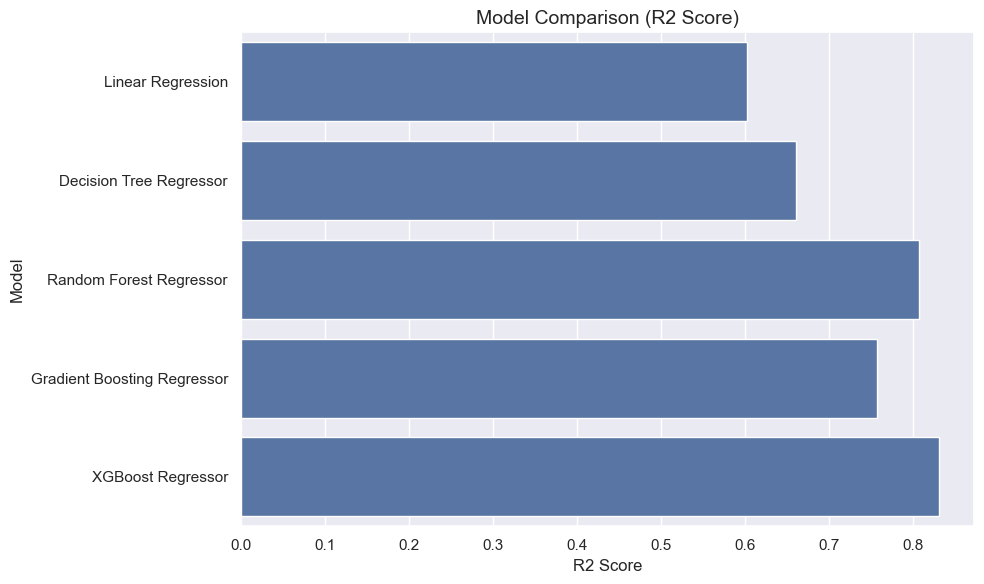

In [52]:
# Store all model scores in a dictionary
model_results = {
    "Linear Regression": r2_lr,
    "Decision Tree Regressor": r2_dt,
    "Random Forest Regressor": r2_rf,
    "Gradient Boosting Regressor": r2_gb,
    "XGBoost Regressor": r2_xgb
}

# Convert to dataframe for better display
results_df = pd.DataFrame(model_results.items(), columns=["Model", "R2 Score"])

print("\n==================== MODEL PERFORMANCE COMPARISON ====================")
print(results_df)
print("=====================================================================\n")

# Find best model
best_model_name = max(model_results, key=model_results.get)
best_model_score = model_results[best_model_name]

print(f"🏆 BEST MODEL: {best_model_name}")
print(f"📈 BEST R2 SCORE: {best_model_score:.4f}")
print(f"🎯 BEST ACCURACY: {best_model_score*100:.2f}%")

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="R2 Score", y="Model")
plt.title("Model Comparison (R2 Score)", fontsize=14)
plt.xlabel("R2 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE PLOT

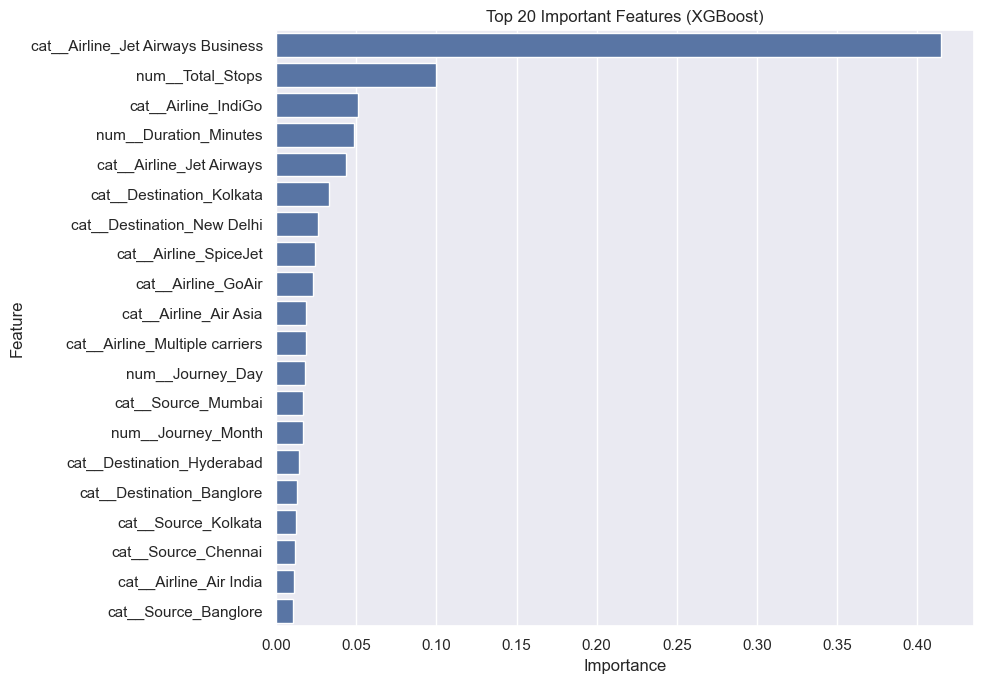

In [50]:
# Get trained XGBoost model from pipeline
xgb_model = model_xgb.named_steps["model"]

# Get feature names from preprocessor
feature_names = model_xgb.named_steps["preprocessor"].get_feature_names_out()

# Get importance scores
importances = xgb_model.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort the top 20 features
importance_df = importance_df.sort_values(by="Importance", ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Top 20 Important Features (XGBoost)")
plt.tight_layout()
plt.show()


## CONCLUSION

-  The XGBoost model achieved the highest prediction accuracy of 83.08%.
-  Duration, Total Stops, and Airline type are the most important factors affecting price.
-  Feature engineering significantly improved model performance.

This project successfully demonstrates the process of building a machine learning–based flight fare prediction system from data loading → cleaning → EDA → feature engineering → model training → evaluation.

# Flight Fare Prediction – Project Report


## 1. Introduction
Flight ticket pricing is highly dynamic and unpredictable due to factors such as airline policies, travel
demand, number of stops, route, time of travel, and seasonality. This project aims to develop a
machine learning model that predicts flight fares based on multiple flight-related features.

## 2. Dataset Description
The dataset contains 10,683 rows and 11 columns. It includes categorical and numerical attributes
such as Airline, Source, Destination, Journey Date, Departure Time, Arrival Time, Duration, Total
Stops, Additional Information, and Price (target variable).

## 3. Exploratory Data Analysis (EDA)
EDA was performed to understand price distribution, trends across airlines, destinations, and
impacts of features on the fare. Boxplots and histograms revealed significant variation in prices
based on airline type, number of stops, and travel duration.

## 4. Data Cleaning
The dataset had minimal missing values (only 1 in Route and Total_Stops). Duplicate rows were
removed. The data types were corrected for date and time fields. No major quality issues were
found.

## 5. Feature Engineering
Key transformations applied: - Extracted Journey Day and Month from Date_of_Journey. -
Extracted hours and minutes from Dep_Time and Arrival_Time. - Converted Duration into total
minutes. - Encoded categorical variables (Airline, Source, Destination) using OneHotEncoder. -
Converted Total_Stops to numerical form. These steps prepared the dataset for model training.

## 6. Model Training
Five regression algorithms were trained: 1. Linear Regression 2. Decision Tree Regressor 3.
Random Forest Regressor 4. Gradient Boosting Regressor 5. XGBoost Regressor Data was split
into 80% training and 20% testing. A preprocessing pipeline with ColumnTransformer was used to
handle categorical and numerical features consistently across all models.

## 7. Model Evaluation
Evaluation metrics used: - Mean Absolute Error (MAE) - Root Mean Square Error (RMSE) - R2
Score (Accuracy) Model Performance: - Linear Regression: 60.20% accuracy - Decision Tree:
66.09% accuracy - Gradient Boosting: 75.70% accuracy - Random Forest: 80.66% accuracy -
XGBoost: 83.08% accuracy (Best Model) XGBoost outperformed all other models and was selected
as the final prediction model.

## 8. Feature Importance
The top contributing features included: - Total Stops - Duration (Minutes) - Airline type These
factors significantly influence fare variations. XGBoost's feature importance plot highlighted that
number of stops and flight duration were the strongest predictors of price.

## 9. Conclusion
The project successfully predicted flight fares using various machine learning models. XGBoost
Regressor achieved the best accuracy (83%), demonstrating strong predictive capability. This
model can help airlines optimize pricing strategies and assist customers in understanding fare
trends. Future enhancements: - Include seasonal and holiday data - Add seat class and
demand-based pricing variables - Deploy model as a web application